# Comparison of CNNs: AlexNet and MobileNetV2

#### Authors: Pérez Luis, Brandan and De Valenzuela Bandín, Fernando


# Preparation

## Libraries

In [1]:
import time
import copy
import datetime

from statistics import mean

import torch
from torch import nn
from torchvision.datasets import MNIST, FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info
from tabulate import tabulate

##  Reproducibility and device configuration

To ensure consistent results across executions, we fix the random seed and configure deterministic behavior in PyTorch.

We also detect whether a CUDA-enabled GPU is available and select the appropriate device for training and inference.

In [2]:
# Reproducibility
torch.manual_seed(20)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.manual_seed_all(20)
else:
    print("Using CPU (no GPU available)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device selected: {device}")

Using GPU: NVIDIA GeForce GTX 1060
Device selected: cuda


## Dataset loading and preprocessing

We use MNIST as the source dataset for the first set of experiments. Since AlexNet and MobileNetV2 are designed for larger RGB-like inputs, the original 28×28 grayscale images are resized to 224×224 and replicated to 3 channels.

To follow a more rigorous evaluation protocol, the original MNIST training split is further divided into a training subset and a validation subset. The official MNIST test split is reserved for final evaluation only.

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
TRAIN_RATIO = 0.9

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Full MNIST training split
full_train_set = MNIST('./data', train=True, transform=transform, download=True)

# Official MNIST test split
test_set = MNIST('./data', train=False, transform=transform, download=True)

# Split training data into train and validation subsets
train_size = int(TRAIN_RATIO * len(full_train_set))
val_size = len(full_train_set) - train_size

split_generator = torch.Generator().manual_seed(20)
train_set, val_set = random_split(full_train_set, [train_size, val_size], generator=split_generator)

CHANNEL_NUM = full_train_set[0][0].shape[0]
NUM_CLASSES = len(full_train_set.classes)

# Data loaders
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print(f'Train set size: {len(train_set)}')
print(f'Validation set size: {len(val_set)}')
print(f'Test set size: {len(test_set)}')
print(f'Number of channels: {CHANNEL_NUM}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {full_train_set.classes}')

Train set size: 54000
Validation set size: 6000
Test set size: 10000
Number of channels: 3
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## Sample visualization

We visualize a sample from the dataset after preprocessing to verify that the transformations (resizing, channel expansion, and normalization) have been correctly applied.

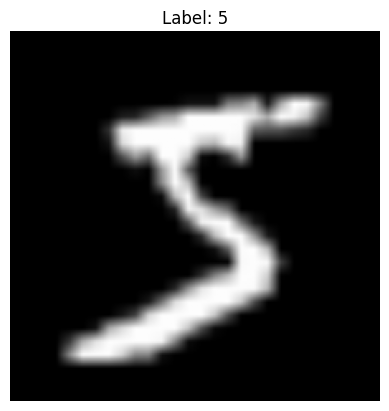

In [4]:
img, label = full_train_set[0]

img_to_show = img.permute(1, 2, 0).numpy()
img_to_show = (img_to_show * 0.5) + 0.5  # desnormalizar

plt.imshow(img_to_show)
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()

## Training and validation functions

The following functions implement the training and validation workflow used throughout the experiments.

For each epoch, we compute:
- average cross-entropy loss,
- Top-1 accuracy,
- Top-5 accuracy.

The best model is selected according to the lowest validation loss and restored at the end of training.

In [5]:
def train_one_epoch(model, loss_fn, optimizer, data_loader):
    total_loss = 0.0
    running_loss = 0.0
    total_top1_correct = 0
    total_top5_correct = 0
    total_samples = 0
    num_batches = 0

    for i, (inputs, labels) in enumerate(data_loader):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        total_loss += batch_loss
        running_loss += batch_loss
        num_batches += 1

        _, top1_preds = torch.topk(outputs, 1, dim=1)
        correct_top1 = (top1_preds == labels.unsqueeze(1)).any(dim=1)
        total_top1_correct += correct_top1.sum().item()

        k = min(5, outputs.shape[1])
        _, top5_preds = torch.topk(outputs, k, dim=1)
        correct_top5 = (top5_preds == labels.unsqueeze(1)).any(dim=1)
        total_top5_correct += correct_top5.sum().item()

        total_samples += labels.size(0)

        if i % 1000 == 999:
            print(f"  batch {i + 1} loss: {running_loss / 1000:.4f}")
            running_loss = 0.0

    avg_loss = total_loss / num_batches
    top1_accuracy = total_top1_correct / total_samples
    top5_accuracy = total_top5_correct / total_samples

    metrics = {
        'top1_accuracy': top1_accuracy,
        'top5_accuracy': top5_accuracy
    }

    return avg_loss, metrics

In [6]:
def validate_one_epoch(model, loss_fn, data_loader):
    running_vloss = 0.0
    total_top1_correct = 0
    total_top5_correct = 0
    total_samples = 0
    num_batches = 0

    model.eval()

    with torch.no_grad():
        for vinputs, vlabels in data_loader:
            vinputs = vinputs.to(device, non_blocking=True)
            vlabels = vlabels.to(device, non_blocking=True)

            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)

            running_vloss += vloss.item()
            num_batches += 1

            _, top1_preds = torch.topk(voutputs, 1, dim=1)
            correct_top1 = (top1_preds == vlabels.unsqueeze(1)).any(dim=1)
            total_top1_correct += correct_top1.sum().item()

            k = min(5, voutputs.shape[1])
            _, top5_preds = torch.topk(voutputs, k, dim=1)
            correct_top5 = (top5_preds == vlabels.unsqueeze(1)).any(dim=1)
            total_top5_correct += correct_top5.sum().item()

            total_samples += vlabels.size(0)

    avg_vloss = running_vloss / num_batches
    top1_accuracy = total_top1_correct / total_samples
    top5_accuracy = total_top5_correct / total_samples

    metrics = {
        'top1_accuracy': top1_accuracy,
        'top5_accuracy': top5_accuracy
    }

    return avg_vloss, metrics

In [7]:
def train_model(model, loss_fn, optimizer, training_loader, validation_loader,
                epochs=10, save_best_model=True, best_model_name=None):
    best_vloss = float('inf')
    best_model = None
    train_losses = []
    val_losses = []

    training_start = time.time_ns()
    epoch_times = []

    for epoch in range(epochs):
        print(f"\nEPOCH {epoch + 1}:")

        epoch_start = time.time_ns()
        model.train(True)

        avg_loss, train_metrics = train_one_epoch(model, loss_fn, optimizer, training_loader)
        avg_vloss, val_metrics = validate_one_epoch(model, loss_fn, validation_loader)

        epoch_times.append(time.time_ns() - epoch_start)

        print(f"Loss: Train: {avg_loss:.4f} | Valid: {avg_vloss:.4f}")
        print(f"Top-1 Accuracy: Train: {train_metrics['top1_accuracy'] * 100:.2f}% | Valid: {val_metrics['top1_accuracy'] * 100:.2f}%")
        print(f"Top-5 Accuracy: Train: {train_metrics['top5_accuracy'] * 100:.2f}% | Valid: {val_metrics['top5_accuracy'] * 100:.2f}%")

        train_losses.append(avg_loss)
        val_losses.append(avg_vloss)

        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            best_model = copy.deepcopy(model.state_dict())

    training_time = time.time_ns() - training_start

    metrics = {
        'total_time': training_time / 1e9,
        'average_epoch_time': mean(epoch_times) / 1e9
    }

    print(f"\nTraining duration: {metrics['total_time']:.3f} s")
    print(f"Average epoch duration: {metrics['average_epoch_time']:.3f} s")

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label='Train loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation loss')
    plt.title('Loss evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if save_best_model and best_model is not None:
        if best_model_name is None:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            best_model_name = f'model_{timestamp}.pt'
        torch.save(best_model, best_model_name)

    if best_model is not None:
        model.load_state_dict(best_model)

    return model, metrics

# AlexNet

In [8]:
class AlexNet(nn.Module):
    """
    AlexNet-style architecture for 224x224 input images.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.LazyConv2d(256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.LazyConv2d(384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.LazyConv2d(384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.LazyConv2d(256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.LazyLinear(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


EPOCH 1:
  batch 1000 loss: 0.3968
Loss: Train: 0.2963 | Valid: 0.1096
Top-1 Accuracy: Train: 90.41% | Valid: 96.60%
Top-5 Accuracy: Train: 97.97% | Valid: 99.95%

EPOCH 2:
  batch 1000 loss: 0.1441
Loss: Train: 0.1348 | Valid: 0.0624
Top-1 Accuracy: Train: 96.36% | Valid: 98.20%
Top-5 Accuracy: Train: 99.90% | Valid: 99.97%

EPOCH 3:
  batch 1000 loss: 0.1206
Loss: Train: 0.1165 | Valid: 0.0996
Top-1 Accuracy: Train: 96.91% | Valid: 97.08%
Top-5 Accuracy: Train: 99.91% | Valid: 99.98%

EPOCH 4:
  batch 1000 loss: 0.1350
Loss: Train: 0.1269 | Valid: 0.0510
Top-1 Accuracy: Train: 96.70% | Valid: 98.58%
Top-5 Accuracy: Train: 99.87% | Valid: 99.98%

EPOCH 5:
  batch 1000 loss: 0.1052
Loss: Train: 0.0998 | Valid: 0.0686
Top-1 Accuracy: Train: 97.35% | Valid: 98.03%
Top-5 Accuracy: Train: 99.92% | Valid: 99.97%

Training duration: 1344.744 s
Average epoch duration: 268.942 s


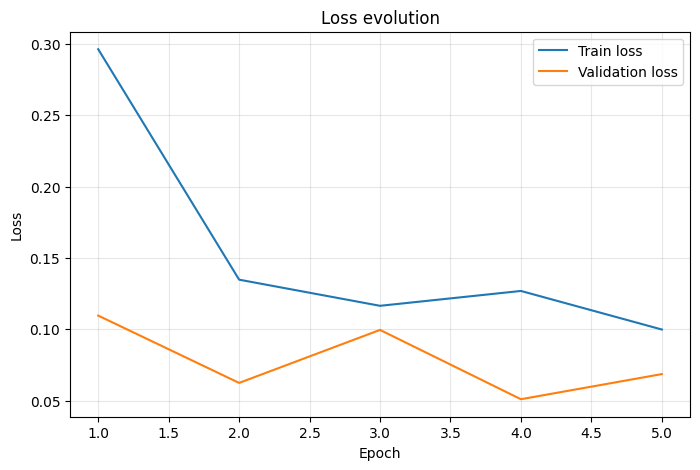

In [9]:
EPOCHS = 5

alexnet_model = AlexNet(num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(alexnet_model.parameters(), lr=1e-3)

trained_alexnet, alexnet_training_metrics = train_model(
    model=alexnet_model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    training_loader=train_loader,
    validation_loader=val_loader,
    epochs=EPOCHS,
    best_model_name='best_alexnet.pt'
)

### AlexNet training observations

AlexNet converged well on MNIST, reaching high Top-1 validation accuracy and near-saturated Top-5 accuracy.  
The validation loss showed some fluctuations across epochs, but overall training remained stable and the model achieved strong multiclass classification performance.

The computational cost was relatively high due to the large 224×224 input size and the heavy fully connected layers in AlexNet, which will later be compared against MobileNetV2.

Training times should be interpreted in the context of the available hardware.  
All experiments were executed under the same hardware conditions, using an NVIDIA GeForce GTX 1060 GPU. Therefore, runtime comparisons between AlexNet and MobileNetV2 remain fair even if absolute training times are relatively high.

# MobileNetV2

## MobileNetV2 definition and training

As the second architecture, we implement MobileNetV2 from scratch.  
This model is designed to be computationally more efficient than AlexNet by using depthwise separable convolutions and inverted residual blocks.

To ensure a fair comparison, MobileNetV2 is trained from scratch under the same experimental setup used for AlexNet.

In [10]:
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU6(inplace=True)
        )

In [11]:
class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        hidden_dim = int(round(in_channels * expand_ratio))
        self.use_residual = (self.stride == 1 and in_channels == out_channels)

        layers = []

        # Expansion
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1))

        # Depthwise
        layers.append(ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, groups=hidden_dim))

        # Projection
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [12]:
class MobileNetV2Custom(nn.Module):
    def __init__(self, num_classes=10, width_mult=1.0):
        super().__init__()

        def c(channels):
            return int(channels * width_mult)

        self.features = nn.Sequential(
            ConvBNReLU(3, c(32), stride=2),

            InvertedResidual(c(32),  c(16),  stride=1, expand_ratio=1),

            InvertedResidual(c(16),  c(24),  stride=2, expand_ratio=6),
            InvertedResidual(c(24),  c(24),  stride=1, expand_ratio=6),

            InvertedResidual(c(24),  c(32),  stride=2, expand_ratio=6),
            InvertedResidual(c(32),  c(32),  stride=1, expand_ratio=6),
            InvertedResidual(c(32),  c(32),  stride=1, expand_ratio=6),

            InvertedResidual(c(32),  c(64),  stride=2, expand_ratio=6),
            InvertedResidual(c(64),  c(64),  stride=1, expand_ratio=6),
            InvertedResidual(c(64),  c(64),  stride=1, expand_ratio=6),
            InvertedResidual(c(64),  c(64),  stride=1, expand_ratio=6),

            InvertedResidual(c(64),  c(96),  stride=1, expand_ratio=6),
            InvertedResidual(c(96),  c(96),  stride=1, expand_ratio=6),
            InvertedResidual(c(96),  c(96),  stride=1, expand_ratio=6),

            InvertedResidual(c(96),  c(160), stride=2, expand_ratio=6),
            InvertedResidual(c(160), c(160), stride=1, expand_ratio=6),
            InvertedResidual(c(160), c(160), stride=1, expand_ratio=6),

            InvertedResidual(c(160), c(320), stride=1, expand_ratio=6),

            ConvBNReLU(c(320), c(1280), kernel_size=1, stride=1)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(c(1280), num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


EPOCH 1:
  batch 1000 loss: 0.1951
Loss: Train: 0.1463 | Valid: 0.0542
Top-1 Accuracy: Train: 95.39% | Valid: 98.30%
Top-5 Accuracy: Train: 99.63% | Valid: 99.97%

EPOCH 2:
  batch 1000 loss: 0.0654
Loss: Train: 0.0624 | Valid: 0.0422
Top-1 Accuracy: Train: 98.08% | Valid: 98.67%
Top-5 Accuracy: Train: 99.98% | Valid: 100.00%

EPOCH 3:
  batch 1000 loss: 0.0495
Loss: Train: 0.0486 | Valid: 0.0335
Top-1 Accuracy: Train: 98.54% | Valid: 99.05%
Top-5 Accuracy: Train: 99.98% | Valid: 100.00%

EPOCH 4:
  batch 1000 loss: 0.0449
Loss: Train: 0.0448 | Valid: 0.0238
Top-1 Accuracy: Train: 98.64% | Valid: 99.30%
Top-5 Accuracy: Train: 99.99% | Valid: 100.00%

EPOCH 5:
  batch 1000 loss: 0.0361
Loss: Train: 0.0369 | Valid: 0.0273
Top-1 Accuracy: Train: 98.84% | Valid: 99.25%
Top-5 Accuracy: Train: 99.99% | Valid: 100.00%

Training duration: 2478.719 s
Average epoch duration: 495.682 s


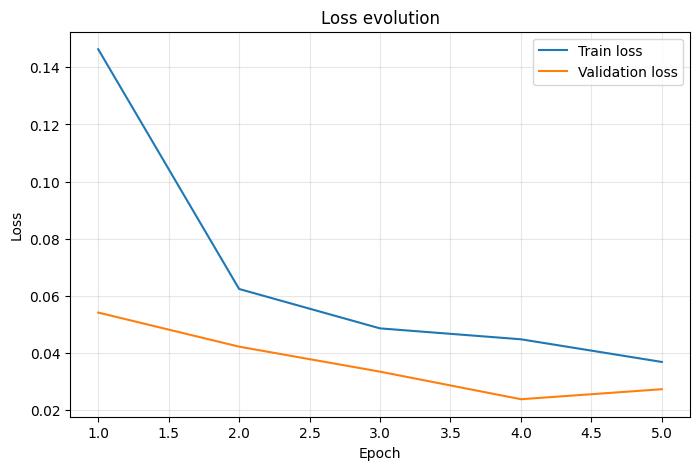

In [13]:
EPOCHS = 5

mobilenetv2_model = MobileNetV2Custom(num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(mobilenetv2_model.parameters(), lr=1e-3)

trained_mobilenetv2, mobilenet_training_metrics = train_model(
    model=mobilenetv2_model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    training_loader=train_loader,
    validation_loader=val_loader,
    epochs=EPOCHS,
    best_model_name='best_mobilenetv2.pt'
)

## 7. Final evaluation and efficiency comparison


After training both models, we evaluate them on the held-out test set.  
In addition to classification performance, we also compare their computational characteristics, including:

- Top-1 accuracy
- Top-5 accuracy
- inference time
- number of parameters
- approximate model size
- training time

These metrics allow us to compare predictive performance and computational efficiency under the same experimental conditions.

In [14]:
# Function to evaluate the final models on the test set

def evaluate_model(model, loss_fn, data_loader):
    model.eval()

    total_loss = 0.0
    total_top1_correct = 0
    total_top5_correct = 0
    total_samples = 0
    num_batches = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()
            num_batches += 1

            _, top1_preds = torch.topk(outputs, 1, dim=1)
            correct_top1 = (top1_preds == labels.unsqueeze(1)).any(dim=1)
            total_top1_correct += correct_top1.sum().item()

            k = min(5, outputs.shape[1])
            _, top5_preds = torch.topk(outputs, k, dim=1)
            correct_top5 = (top5_preds == labels.unsqueeze(1)).any(dim=1)
            total_top5_correct += correct_top5.sum().item()

            total_samples += labels.size(0)

    avg_loss = total_loss / num_batches
    top1_accuracy = total_top1_correct / total_samples
    top5_accuracy = total_top5_correct / total_samples

    return {
        'loss': avg_loss,
        'top1_accuracy': top1_accuracy,
        'top5_accuracy': top5_accuracy
    }

In [15]:
# Evaluate the final models on the test set

alexnet_test_metrics = evaluate_model(trained_alexnet, loss_fn, test_loader)
mobilenet_test_metrics = evaluate_model(trained_mobilenetv2, loss_fn, test_loader)

print("AlexNet test results")
print(f"Loss: {alexnet_test_metrics['loss']:.4f}")
print(f"Top-1 Accuracy: {alexnet_test_metrics['top1_accuracy'] * 100:.2f}%")
print(f"Top-5 Accuracy: {alexnet_test_metrics['top5_accuracy'] * 100:.2f}%")

print("\nMobileNetV2 test results")
print(f"Loss: {mobilenet_test_metrics['loss']:.4f}")
print(f"Top-1 Accuracy: {mobilenet_test_metrics['top1_accuracy'] * 100:.2f}%")
print(f"Top-5 Accuracy: {mobilenet_test_metrics['top5_accuracy'] * 100:.2f}%")

AlexNet test results
Loss: 0.0607
Top-1 Accuracy: 98.23%
Top-5 Accuracy: 99.95%

MobileNetV2 test results
Loss: 0.0247
Top-1 Accuracy: 99.15%
Top-5 Accuracy: 100.00%


In [16]:
# Function to measure inference time of a model on a given data loader

def measure_inference_time(model, data_loader, warmup_batches=5):
    model.eval()

    # Warm-up
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            inputs = inputs.to(device, non_blocking=True)
            _ = model(inputs)
            if i + 1 >= warmup_batches:
                break

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    total_samples = 0
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            _ = model(inputs)
            total_samples += inputs.size(0)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    total_time = end_time - start_time
    time_per_image = total_time / total_samples
    images_per_second = total_samples / total_time

    return {
        'total_time_s': total_time,
        'time_per_image_s': time_per_image,
        'images_per_second': images_per_second
    }

In [17]:
# Measure inference time for both models on the test set

alexnet_inference = measure_inference_time(trained_alexnet, test_loader)
mobilenet_inference = measure_inference_time(trained_mobilenetv2, test_loader)

print("AlexNet inference")
print(f"Total inference time: {alexnet_inference['total_time_s']:.4f} s")
print(f"Average time per image: {alexnet_inference['time_per_image_s']:.6f} s")
print(f"Images per second: {alexnet_inference['images_per_second']:.2f}")

print("\nMobileNetV2 inference")
print(f"Total inference time: {mobilenet_inference['total_time_s']:.4f} s")
print(f"Average time per image: {mobilenet_inference['time_per_image_s']:.6f} s")
print(f"Images per second: {mobilenet_inference['images_per_second']:.2f}")

AlexNet inference
Total inference time: 23.8427 s
Average time per image: 0.002384 s
Images per second: 419.42

MobileNetV2 inference
Total inference time: 29.6929 s
Average time per image: 0.002969 s
Images per second: 336.78


In [18]:
# Additional utility functions to count parameters and calculate model size in MB

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

In [19]:
# Calculate and print MACs and parameter count using ptflops

alexnet_macs, alexnet_params_ptflops = get_model_complexity_info(
    trained_alexnet,
    (3, 224, 224),
    as_strings=True,
    print_per_layer_stat=False,
    verbose=False
)

mobilenet_macs, mobilenet_params_ptflops = get_model_complexity_info(
    trained_mobilenetv2,
    (3, 224, 224),
    as_strings=True,
    print_per_layer_stat=False,
    verbose=False
)

print("AlexNet")
print("MACs:", alexnet_macs)
print("Params:", alexnet_params_ptflops)

print("\nMobileNetV2")
print("MACs:", mobilenet_macs)
print("Params:", mobilenet_params_ptflops)

AlexNet
MACs: 1.01 GMac
Params: 46.79 M

MobileNetV2
MACs: 319.09 MMac
Params: 2.24 M


In [20]:
# Create a comparison table for the two models

comparison_table = [
    [
        "AlexNet",
        f"{alexnet_test_metrics['top1_accuracy'] * 100:.2f}%",
        f"{alexnet_test_metrics['top5_accuracy'] * 100:.2f}%",
        f"{count_parameters(trained_alexnet):,}",
        f"{model_size_mb(trained_alexnet):.2f} MB",
        alexnet_macs,
        f"{alexnet_inference['total_time_s']:.4f} s",
        f"{alexnet_inference['time_per_image_s']:.6f} s",
        f"{alexnet_training_metrics['total_time']:.6f} s",
        f"{alexnet_training_metrics['average_epoch_time']:.6f} s"
    ],
    [
        "MobileNetV2",
        f"{mobilenet_test_metrics['top1_accuracy'] * 100:.2f}%",
        f"{mobilenet_test_metrics['top5_accuracy'] * 100:.2f}%",
        f"{count_parameters(trained_mobilenetv2):,}",
        f"{model_size_mb(trained_mobilenetv2):.2f} MB",
        mobilenet_macs,
        f"{mobilenet_inference['total_time_s']:.4f} s",
        f"{mobilenet_inference['time_per_image_s']:.6f} s",
        f"{mobilenet_training_metrics['total_time']:.6f} s",
        f"{mobilenet_training_metrics['average_epoch_time']:.6f} s"
    ]
]

headers = [
    "Model",
    "Top-1 Test",
    "Top-5 Test",
    "Parameters",
    "Model Size",
    "MACs",
    "Inference Time (test set)",
    "Time / Image",
    "Training Time",
    "Average training time / Epoch"
]

print(tabulate(comparison_table, headers=headers, tablefmt="github"))

| Model       | Top-1 Test   | Top-5 Test   |   Parameters | Model Size   | MACs        | Inference Time (test set)   | Time / Image   | Training Time   | Average training time / Epoch   |
|-------------|--------------|--------------|--------------|--------------|-------------|-----------------------------|----------------|-----------------|---------------------------------|
| AlexNet     | 98.23%       | 99.95%       |   46,787,978 | 178.48 MB    | 1.01 GMac   | 23.8427 s                   | 0.002384 s     | 1344.744422 s   | 268.942414 s                    |
| MobileNetV2 | 99.15%       | 100.00%      |    2,236,682 | 8.53 MB      | 319.09 MMac | 29.6929 s                   | 0.002969 s     | 2478.719012 s   | 495.682103 s                    |


### Comparative observations

AlexNet and MobileNetV2 both achieved strong performance on MNIST. However, the two architectures differ substantially in their computational profiles.

AlexNet is expected to be heavier due to its large convolutional filters and fully connected layers, while MobileNetV2 is designed to reduce parameter count and theoretical computational cost through inverted residual blocks and depthwise separable convolutions.

Interestingly, real execution time may differ from theoretical efficiency depending on the hardware and software stack. In our experiments, both models were evaluated under the same conditions, making the comparison fair even when practical runtime does not perfectly match theoretical expectations.

Although MobileNetV2 significantly reduces the number of parameters and theoretical computational cost (MACs), it was slower than AlexNet in both training and inference time on the available hardware (NVIDIA GeForce GTX 1060).

This can be explained by the fact that depthwise separable convolutions, which are central to MobileNetV2, are not always as well optimized on older GPUs as standard convolutions. As a result, theoretical efficiency does not always translate into faster real-world execution.

Regarding convergence, both models showed stable learning behavior on MNIST.

AlexNet exhibited slightly more fluctuation in validation loss across epochs, suggesting some sensitivity to overfitting or optimization dynamics. In contrast, MobileNetV2 showed smoother convergence and achieved lower validation loss earlier.

However, MobileNetV2 required longer training time per epoch, indicating that convergence speed in terms of epochs does not necessarily translate into faster wall-clock training time.

# Transfer Learning

## Transfer learning from MNIST to FashionMNIST

To study transfer learning, the two models previously trained on MNIST are reused and fine-tuned on FashionMNIST.

This experiment evaluates whether features learned from handwritten digit classification can be transferred to a different grayscale image classification task involving clothing categories.

Since both MNIST and FashionMNIST contain 10 classes, the output dimensionality remains unchanged and the previously trained models can be directly reused and fine-tuned.

In [21]:
# FashionMNIST datasets
fashion_full_train_set = FashionMNIST('./data', train=True, transform=transform, download=True)
fashion_test_set = FashionMNIST('./data', train=False, transform=transform, download=True)

fashion_train_size = int(TRAIN_RATIO * len(fashion_full_train_set))
fashion_val_size = len(fashion_full_train_set) - fashion_train_size

fashion_split_generator = torch.Generator().manual_seed(20)
fashion_train_set, fashion_val_set = random_split(
    fashion_full_train_set,
    [fashion_train_size, fashion_val_size],
    generator=fashion_split_generator
)

fashion_train_loader = DataLoader(
    fashion_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

fashion_val_loader = DataLoader(
    fashion_val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

fashion_test_loader = DataLoader(
    fashion_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print(f'FashionMNIST train set size: {len(fashion_train_set)}')
print(f'FashionMNIST validation set size: {len(fashion_val_set)}')
print(f'FashionMNIST test set size: {len(fashion_test_set)}')
print(f'FashionMNIST classes: {fashion_full_train_set.classes}')

FashionMNIST train set size: 54000
FashionMNIST validation set size: 6000
FashionMNIST test set size: 10000
FashionMNIST classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### FashionMNIST data preparation

FashionMNIST is loaded using the same preprocessing pipeline used for MNIST, including resizing to 224×224, channel replication to 3 channels, tensor conversion, and normalization.

The official training split is divided into training and validation subsets, while the official test split is kept exclusively for final evaluation.


EPOCH 1:
  batch 1000 loss: 0.7065
Loss: Train: 0.6210 | Valid: 0.3980
Top-1 Accuracy: Train: 77.51% | Valid: 84.70%
Top-5 Accuracy: Train: 98.64% | Valid: 99.65%

EPOCH 2:
  batch 1000 loss: 0.4431
Loss: Train: 0.4312 | Valid: 0.4468
Top-1 Accuracy: Train: 84.29% | Valid: 83.38%
Top-5 Accuracy: Train: 99.69% | Valid: 99.65%

EPOCH 3:
  batch 1000 loss: 0.4153
Loss: Train: 0.4091 | Valid: 0.3564
Top-1 Accuracy: Train: 85.09% | Valid: 86.60%
Top-5 Accuracy: Train: 99.69% | Valid: 99.77%

EPOCH 4:
  batch 1000 loss: 0.3769
Loss: Train: 0.3796 | Valid: 0.3317
Top-1 Accuracy: Train: 86.24% | Valid: 87.63%
Top-5 Accuracy: Train: 99.75% | Valid: 99.73%

EPOCH 5:
  batch 1000 loss: 0.3657
Loss: Train: 0.3624 | Valid: 0.3367
Top-1 Accuracy: Train: 86.72% | Valid: 87.20%
Top-5 Accuracy: Train: 99.75% | Valid: 99.77%

Training duration: 1334.774 s
Average epoch duration: 266.951 s


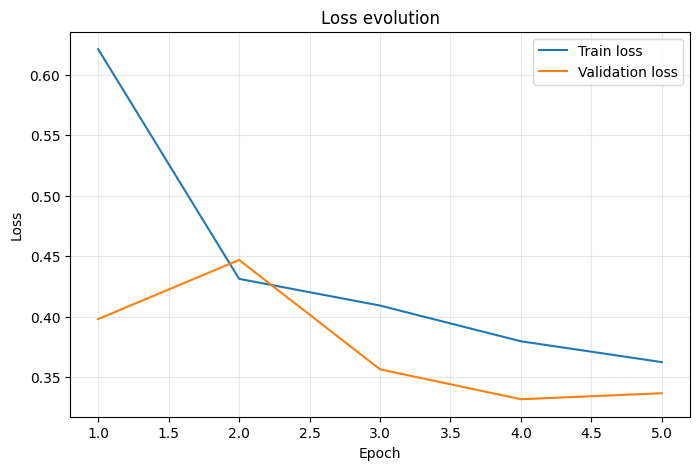

In [22]:
TRANSFER_EPOCHS = 5

alexnet_transfer = AlexNet(num_classes=10).to(device)
alexnet_transfer.load_state_dict(trained_alexnet.state_dict())

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(alexnet_transfer.parameters(), lr=1e-3)

trained_alexnet_transfer, _ = train_model(
    model=alexnet_transfer,
    loss_fn=loss_fn,
    optimizer=optimizer,
    training_loader=fashion_train_loader,
    validation_loader=fashion_val_loader,
    epochs=TRANSFER_EPOCHS,
    best_model_name='fashion_alexnet_transfer.pt'
)

### AlexNet transfer learning results

The AlexNet model pre-trained on MNIST was fine-tuned on FashionMNIST.  

The model achieved a validation accuracy of approximately 87–88%, significantly lower than its performance on MNIST (~98%). This reflects the increased difficulty of FashionMNIST and the domain difference between handwritten digits and clothing images.

However, the model did not start from random performance levels, but instead reached high accuracy already in the first epoch (~85%), indicating that previously learned features were partially transferable.

The training process was stable, with decreasing loss and no major convergence issues. A slight increase in validation loss in the final epoch suggests mild overfitting.

### MobileNetV2 transfer learning

The MobileNetV2 model trained on MNIST is also reused and fine-tuned on FashionMNIST.

As in the AlexNet experiment, full fine-tuning is applied so that all layers can adapt to the new dataset.


EPOCH 1:
  batch 1000 loss: 0.4853
Loss: Train: 0.4162 | Valid: 0.2686
Top-1 Accuracy: Train: 85.83% | Valid: 90.18%
Top-5 Accuracy: Train: 99.46% | Valid: 99.85%

EPOCH 2:
  batch 1000 loss: 0.2644
Loss: Train: 0.2621 | Valid: 0.2369
Top-1 Accuracy: Train: 90.65% | Valid: 91.08%
Top-5 Accuracy: Train: 99.88% | Valid: 99.85%

EPOCH 3:
  batch 1000 loss: 0.2313
Loss: Train: 0.2293 | Valid: 0.2644
Top-1 Accuracy: Train: 91.76% | Valid: 90.10%
Top-5 Accuracy: Train: 99.91% | Valid: 99.82%

EPOCH 4:
  batch 1000 loss: 0.2018
Loss: Train: 0.2058 | Valid: 0.2438
Top-1 Accuracy: Train: 92.53% | Valid: 91.17%
Top-5 Accuracy: Train: 99.92% | Valid: 99.85%

EPOCH 5:
  batch 1000 loss: 0.1845
Loss: Train: 0.1867 | Valid: 0.2091
Top-1 Accuracy: Train: 93.17% | Valid: 92.43%
Top-5 Accuracy: Train: 99.95% | Valid: 99.97%

Training duration: 2535.590 s
Average epoch duration: 507.073 s


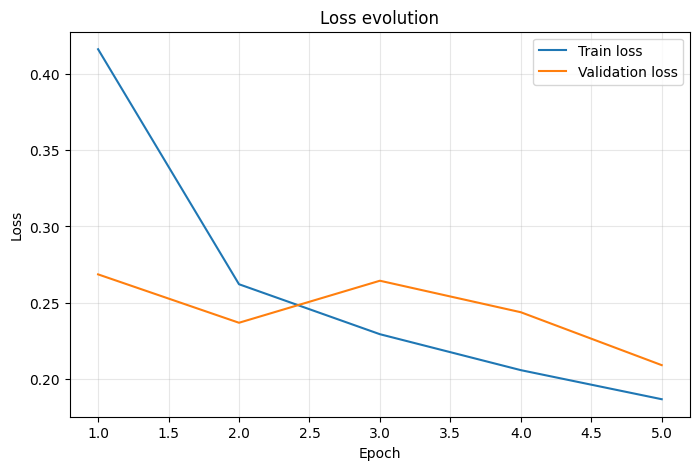

In [23]:
mobilenet_transfer = MobileNetV2Custom(num_classes=10).to(device)
mobilenet_transfer.load_state_dict(trained_mobilenetv2.state_dict())

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(mobilenet_transfer.parameters(), lr=1e-3)

trained_mobilenet_transfer, _ = train_model(
    model=mobilenet_transfer,
    loss_fn=loss_fn,
    optimizer=optimizer,
    training_loader=fashion_train_loader,
    validation_loader=fashion_val_loader,
    epochs=TRANSFER_EPOCHS,
    best_model_name='fashion_mobilenet_transfer.pt'
)

### MobileNetV2 transfer learning results

The MobileNetV2 model pre-trained on MNIST was fine-tuned on FashionMNIST.

In this case, transfer learning produced stronger results than with AlexNet, reaching a validation accuracy above 93% and showing a more consistent decrease in both training and validation loss over the epochs.

As with AlexNet, performance remained below the original MNIST results, which is expected because FashionMNIST represents a more challenging and visually different domain. Nevertheless, the model started from a strong initial point and adapted effectively to the target dataset, indicating that the learned representations were meaningfully transferable.

Compared with AlexNet, MobileNetV2 showed better transfer performance, although it also required more training time on the available hardware.

### Final evaluation of transferred models

After fine-tuning both transferred models on FashionMNIST, we evaluate them on the held-out FashionMNIST test set.

This final test evaluation provides the transfer learning results used in the comparative discussion.

In [24]:
alexnet_transfer_test = evaluate_model(trained_alexnet_transfer, loss_fn, fashion_test_loader)
mobilenet_transfer_test = evaluate_model(trained_mobilenet_transfer, loss_fn, fashion_test_loader)

print("AlexNet transfer learning on FashionMNIST")
print(f"Loss: {alexnet_transfer_test['loss']:.4f}")
print(f"Top-1 Accuracy: {alexnet_transfer_test['top1_accuracy'] * 100:.2f}%")
print(f"Top-5 Accuracy: {alexnet_transfer_test['top5_accuracy'] * 100:.2f}%")

print("\nMobileNetV2 transfer learning on FashionMNIST")
print(f"Loss: {mobilenet_transfer_test['loss']:.4f}")
print(f"Top-1 Accuracy: {mobilenet_transfer_test['top1_accuracy'] * 100:.2f}%")
print(f"Top-5 Accuracy: {mobilenet_transfer_test['top5_accuracy'] * 100:.2f}%")

AlexNet transfer learning on FashionMNIST
Loss: 0.3436
Top-1 Accuracy: 87.46%
Top-5 Accuracy: 99.82%

MobileNetV2 transfer learning on FashionMNIST
Loss: 0.2119
Top-1 Accuracy: 92.38%
Top-5 Accuracy: 99.96%


### Transfer learning summary

The following table summarizes the performance of both models after transfer learning from MNIST to FashionMNIST.

In [25]:
transfer_summary = [
    [
        "AlexNet",
        f"{alexnet_transfer_test['loss']:.4f}",
        f"{alexnet_transfer_test['top1_accuracy'] * 100:.2f}%",
        f"{alexnet_transfer_test['top5_accuracy'] * 100:.2f}%"
    ],
    [
        "MobileNetV2",
        f"{mobilenet_transfer_test['loss']:.4f}",
        f"{mobilenet_transfer_test['top1_accuracy'] * 100:.2f}%",
        f"{mobilenet_transfer_test['top5_accuracy'] * 100:.2f}%"
    ]
]

print(tabulate(
    transfer_summary,
    headers=["Model", "Test Loss", "Top-1 Test", "Top-5 Test"],
    tablefmt="github"
))

| Model       |   Test Loss | Top-1 Test   | Top-5 Test   |
|-------------|-------------|--------------|--------------|
| AlexNet     |      0.3436 | 87.46%       | 99.82%       |
| MobileNetV2 |      0.2119 | 92.38%       | 99.96%       |


### Findings on transfer learning

Transfer learning from MNIST to FashionMNIST proved to be effective, but its impact depended on the model architecture.

Both models achieved high initial accuracy from the first epoch, indicating that previously learned features (such as edges and basic shapes) were transferable despite the domain difference.

However, performance on FashionMNIST remained significantly lower than on MNIST, confirming that the two datasets differ in visual complexity and semantic content.

MobileNetV2 clearly outperformed AlexNet in the transfer learning scenario, achieving higher Top-1 accuracy (92.38% vs 87.46%) and lower test loss. This suggests that MobileNetV2 learns more generalizable feature representations that adapt better to new tasks.

Overall, transfer learning was beneficial, but its effectiveness was limited by the difference between source and target domains.

## Conclusion

In this study, AlexNet and MobileNetV2 were compared under the same experimental conditions using MNIST and FashionMNIST datasets.

Both models achieved high classification performance on MNIST, with MobileNetV2 slightly outperforming AlexNet in accuracy while using significantly fewer parameters and computational resources.

Despite its theoretical efficiency, MobileNetV2 required more training and inference time than AlexNet on the available hardware, highlighting that theoretical complexity does not always translate into faster execution in practice.

In the transfer learning experiment, both models successfully reused knowledge from MNIST when adapting to FashionMNIST. However, the effectiveness of transfer learning was limited by the domain difference between the datasets.

MobileNetV2 demonstrated superior transfer capabilities, achieving higher accuracy and better generalization, suggesting that its architecture is better suited for learning transferable features.

Overall, the results show that model efficiency, performance, and transferability depend not only on architecture design but also on hardware characteristics and dataset similarity.